In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(r'/content/data (1).csv',encoding='latin1')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.drop(columns={'id','Unnamed: 32'},inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [ ]:
x = df.drop(columns={'diagnosis'})
y = df['diagnosis']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
tr = LabelEncoder()
y_train = tr.fit_transform(y_train)
y_test = tr.transform(y_test)

In [ ]:
y_train[:5]

array([0, 1, 0, 0, 0])

In [ ]:
sd = StandardScaler()
x_train = sd.fit_transform(x_train)
x_test = sd.transform(x_test)


In [ ]:
pd.DataFrame(x_train)
pd.DataFrame(x_test)
pd.DataFrame(y_train)
pd.DataFrame(y_test)


,0
0,0
1,1
2,1
3,0
4,0
...,...
109,0
110,1
111,0
112,0


In [ ]:
x_train.shape

(455, 30)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred= knn.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cls_report = classification_report(y_test, y_pred)
print("Classification Report:\n", cls_report)

Accuracy: 0.9473684210526315
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
# Accuracy on trainning data
y_pred_train = knn.predict(x_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
print("Accuracy on training data:", accuracy_train)

Accuracy on training data: 0.9802197802197802


In [ ]:
cross_val = cross_val_score(knn, x_train, y_train, cv=5)
print("Cross Validation Score:", cross_val)
print("Cross Validation Score Mean:", cross_val.mean())
print("Cross Validation Score Std:", cross_val.std())

Cross Validation Score: [0.96703297 0.95604396 0.98901099 0.96703297 0.92307692]
Cross Validation Score Mean: 0.9604395604395606
Cross Validation Score Std: 0.02153397576073123


In [ ]:
score = []

for i in range(1,16):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  y_pred = knn.predict(x_test)
  score.append(accuracy_score(y_test,y_pred))

print(score)


[0.9385964912280702, 0.9473684210526315, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9473684210526315, 0.956140350877193, 0.9649122807017544, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193, 0.956140350877193]


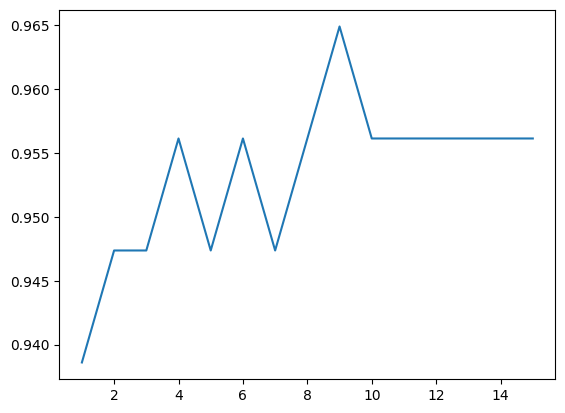

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(1,16),score)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train,y_train)
y_pred = knn.predict(x_test)
accucary = accuracy_score(y_test,y_pred)
print(accucary)

0.9649122807017544


In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv(r'/content/Social_Network_Ads.csv',encoding='latin1')

In [4]:
df = df.iloc[:,1:]


In [5]:
display(df.head())

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [13]:
df = pd.get_dummies(df,columns=['Gender'])

In [14]:
  df.head()

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,False,True
1,35,20000,0,False,True
2,26,43000,0,True,False
3,27,57000,0,True,False
4,19,76000,0,False,True


In [15]:
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [16]:
x = df.drop(columns={'Purchased'})
y = df['Purchased']

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [18]:
st = StandardScaler()

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


x_train = st.fit_transform(x_train)
x_test = st.transform(x_test)

In [19]:
knn= KNeighborsClassifier(n_neighbors=10)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [20]:
y_pred = knn.predict(x_test)

In [21]:
accuracy_score(y_test,y_pred)

0.9375

In [22]:
score = []

for i in range(1,16):
  knn = KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  y_pred = knn.predict(x_test)
  score.append(accuracy_score(y_test,y_pred))

print(score)

[0.8875, 0.8375, 0.9125, 0.9125, 0.925, 0.925, 0.925, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375, 0.9375]


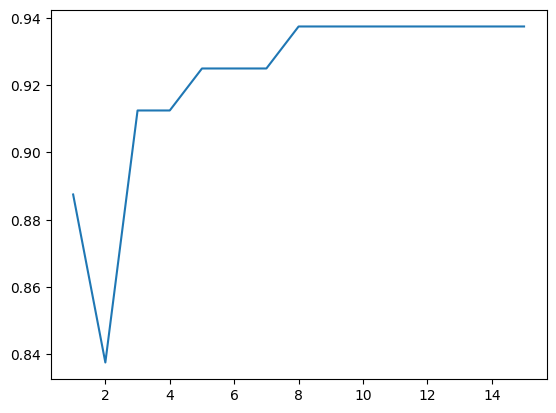

In [23]:
import matplotlib.pyplot as plt
plt.plot(range(1,16),score)

In [27]:
import numpy as np
from collections import Counter

class Knn:

    def __init__(self,k=5):
        self.n_neighbors = k
        self.X_train = None
        self.y_train = None

    def fit(self,X_train,y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self,X_test):

        y_pred = []

        for i in X_test:
            # calculate distance with each training point
            distances = []
            for j in self.X_train:
                distances.append(self.calculate_distance(i,j))
            n_neighbors = sorted(list(enumerate(distances)),key=lambda x:x[1])[0:self.n_neighbors]
            label = self.majority_count(n_neighbors)
            y_pred.append(label)
        return np.array(y_pred)


    def calculate_distance(self,point_A,point_B):
        return np.linalg.norm(point_A - point_B)

    def majority_count(self,neighbors):
        votes = []
        for i in neighbors:
            votes.append(self.y_train.iloc[i[0]])
        votes = Counter(votes)

        return votes.most_common()[0][0]

In [31]:
knn = Knn(k=10)

knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)



In [32]:
accuracy_score(y_test,y_pred)

0.9375